# Library

In [1]:
# !pip install -r requirements.txt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\willi\AppData\Local\Temp\ipykernel_1840\687462750.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Data Load

In [3]:
df = pd.read_json("C:/Project/Deep_Learning_Project/Project-Property/data/raw/properti_raw_v0.json", encoding="utf-8")
# df_update = pd.read_json("C:/Project/Deep_Learning_Project/Project-Property/data/raw/properti_raw_v1.json", encoding="utf-8")

# Data Overview

In [4]:
print(df.shape)
df.head()

(32430, 14)


,url,nama_listing,deskripsi,harga,mata_uang,provinsi,kota,kecamatan,luas_tanah_m2,luas_bangunan_m2,kamar_tidur,kamar_mandi,nama_agen,sku
0,https://www.99.co/id/properti/rumah-dijual-1mi...,Rumah Minimalis 3 KT di Bintara Bekasi Unfurni...,Penawaran istimewa! Jual cepat rumah di Bekasi...,1650000000,IDR,Jawa Barat,Bekasi,None,150.0,135.0,2.0,2.0,Asia One Grand Galaxy,b26e25ef-243d-4e53-985b-82569d07c1b6
1,https://www.99.co/id/properti/kost-dijual-3mil...,"Dijual Rumah Kost di Soekarno Hatta, Malang, 1...","Unit rumah kost dijual di Soekarno Hatta, Mala...",3699000000,IDR,None,Baru,None,250.0,300.0,11.0,5.0,XAVIER MARKS PREMIER MALANG,b9a04fb7-c59a-430a-97c7-b24d50f4442c
2,https://www.99.co/id/properti/hotel-dijual-260...,Titanium Square Apartemen,"Tersedia Hotel di , Bekasi. Titanium Square Ap...",260000000000,IDR,Jawa Barat,Bekasi,None,13115.0,55.0,NaN,NaN,BOSTON PIK 2,e8082d0e-1669-4aab-aebf-2365975d2742
3,https://www.99.co/id/properti/rumah-dijual-875...,"Rumah Terawat Siap Huni di Sbtn Regency, Marga...",Rasakan hidup nyaman di Margaasih Bandung. Rum...,875000000,IDR,Jawa Barat,Bandung,Margaasih,71.0,120.0,5.0,3.0,ERA JACK,dcba8e36-cadf-4c58-8f31-b72fd5adec2a
4,https://www.99.co/id/properti/tanah-dijual-10m...,Dijual Tanah Strategis Dr Susilo Iv Grogol Lua...,Tanah kavling dijual di Jakarta Barat.\n\nSpes...,10800000000,IDR,Jakarta,Jakarta Barat,None,18.0,NaN,NaN,NaN,AVENUE PROPERTY PIK,0d042cc2-0c46-4b2d-8c14-a5f48bc3a23a


In [5]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 32430 entries, 0 to 32429
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               32430 non-null  object 
 1   nama_listing      32430 non-null  object 
 2   deskripsi         32430 non-null  object 
 3   harga             32430 non-null  int64  
 4   mata_uang         32430 non-null  object 
 5   provinsi          31694 non-null  object 
 6   kota              31433 non-null  object 
 7   kecamatan         12988 non-null  object 
 8   luas_tanah_m2     24504 non-null  float64
 9   luas_bangunan_m2  21524 non-null  float64
 10  kamar_tidur       20266 non-null  float64
 11  kamar_mandi       20865 non-null  float64
 12  nama_agen         32430 non-null  object 
 13  sku               32430 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 3.7+ MB
None


,harga,luas_tanah_m2,luas_bangunan_m2,kamar_tidur,kamar_mandi
count,3.243000e+04,2.450400e+04,21524.000000,20266.000000,20865.000000
mean,3.204539e+11,9.619461e+02,548.959208,9.813185,5.638102
std,3.111376e+13,1.166800e+04,7216.774955,529.039518,80.035226
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.500000e+09,9.600000e+01,110.000000,2.000000,2.000000
50%,3.100000e+09,1.700000e+02,200.000000,3.000000,3.000000
75%,7.500000e+09,3.750000e+02,365.000000,4.000000,4.000000
max,5.200000e+15,1.230000e+06,999999.000000,72400.000000,4400.000000


# Handle NA & Duplicated Values

In [6]:
df.isna().sum()

url                     0
nama_listing            0
deskripsi               0
harga                   0
mata_uang               0
provinsi              736
kota                  997
kecamatan           19442
luas_tanah_m2        7926
luas_bangunan_m2    10906
kamar_tidur         12164
kamar_mandi         11565
nama_agen               0
sku                     0
dtype: int64

In [7]:
print("Num of city:", df['kota'].value_counts().count())
print("Num of agen name:", df['nama_agen'].value_counts().count())
print("Num of kecamatan:", df['kecamatan'].value_counts().count())
print(f"Dataset len: {len(df)}; Unique URL: {df['url'].nunique()}")

Num of city: 215
Num of agen name: 2993
Num of kecamatan: 896
Dataset len: 32430; Unique URL: 32429


In [8]:
print(f"Duplicates Values: {df.duplicated().sum()}")

Duplicates Values: 1


In [9]:
df = df.drop_duplicates()

# Handle Irelevant Data & Inconsistence

In [10]:
cat_cols = df.select_dtypes(include='object').columns.to_list()
print(cat_cols)

['url', 'nama_listing', 'deskripsi', 'mata_uang', 'provinsi', 'kota', 'kecamatan', 'nama_agen', 'sku']


In [11]:
unique_cols = [i for i in cat_cols if df[i].nunique() == len(df)]
print(unique_cols)

['url', 'sku']


In [12]:
df = df.drop(columns=unique_cols)

In [13]:
cat_cols = df.select_dtypes(include='object').columns.to_list()
print(cat_cols)

['nama_listing', 'deskripsi', 'mata_uang', 'provinsi', 'kota', 'kecamatan', 'nama_agen']


In [14]:
for i in cat_cols:
    df[i] = df[i].str.strip().str.lower()

In [15]:
# for i in cat_cols:
#     vc = df[i].value_counts()
#     print(f"{vc[vc==1]}\n")

# Handle Numerical Data

In [16]:
num_cols = df.select_dtypes(include='number').columns.to_list()
print(num_cols)

['harga', 'luas_tanah_m2', 'luas_bangunan_m2', 'kamar_tidur', 'kamar_mandi']


In [62]:
df[num_cols].describe()

,harga,luas_tanah_m2,luas_bangunan_m2,kamar_tidur,kamar_mandi
count,3.242900e+04,2.450300e+04,21524.000000,20265.000000,20864.000000
mean,3.204637e+11,9.619803e+02,548.959208,9.813472,5.638229
std,3.111424e+13,1.166824e+04,7216.774955,529.052570,80.037142
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,1.500000e+09,9.600000e+01,110.000000,2.000000,2.000000
50%,3.100000e+09,1.700000e+02,200.000000,3.000000,3.000000
75%,7.500000e+09,3.750000e+02,365.000000,4.000000,4.000000
max,5.200000e+15,1.230000e+06,999999.000000,72400.000000,4400.000000


In [93]:
df_clean = df[
    (df['harga'] > 0) & (df['harga'] < 5e12) &
    (df['kamar_tidur'] <= 500) &
    (df['kamar_mandi'] <= 500) &
    (df['luas_tanah_m2'] > 0) & (df['luas_tanah_m2'] < 100000) &
    (df['luas_bangunan_m2'] > 0) & (df['luas_bangunan_m2'] < 50000)
]

print(f"Data awal: {len(df)}, setelah filter: {len(df_clean)}")

Data awal: 32429, setelah filter: 14724


<Axes: >

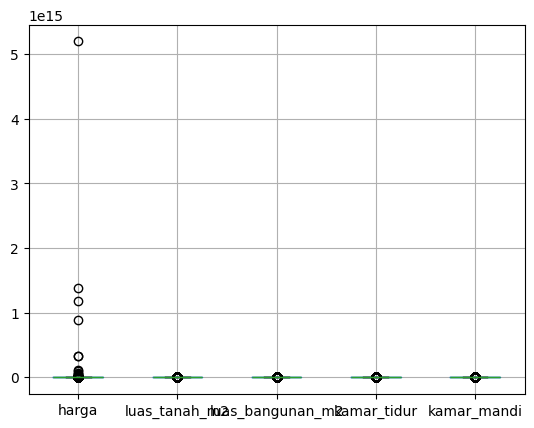

In [97]:
df[num_cols].boxplot()

In [95]:
print("Number of 'harga' (price) values in range 5 trillion - 5.2 quadrillion:", df['harga'][df['harga'].between(5e12, 5.2e15)].count())
print("Number of 'luas_tanah_m2' (land area, m²) values in range 100000 - 1.23e6:", df['luas_tanah_m2'][df['luas_tanah_m2'].between(100000, 1.230000e+06)].count())
print("Number of 'luas_bangunan_m2' (building area, m²) values in range 50000 - 999999:", df['luas_bangunan_m2'][df['luas_bangunan_m2'].between(50000, 999999)].count())
print("Number of 'kamar_tidur' (bedrooms) values in range 500 - 72400:", df['kamar_tidur'][df['kamar_tidur'].between(500, 72400)].count())
print("Number of 'kamar_mandi' (bathrooms) values in range 500 - 4400:", df['kamar_mandi'][df['kamar_mandi'].between(500, 4400)].count())

Number of 'harga' (price) values in range 5 trillion - 5.2 quadrillion: 33
Number of 'luas_tanah_m2' (land area, m²) values in range 100000 - 1.23e6: 21
Number of 'luas_bangunan_m2' (building area, m²) values in range 50000 - 999999: 9
Number of 'kamar_tidur' (bedrooms) values in range 500 - 72400: 12
Number of 'kamar_mandi' (bathrooms) values in range 500 - 4400: 17


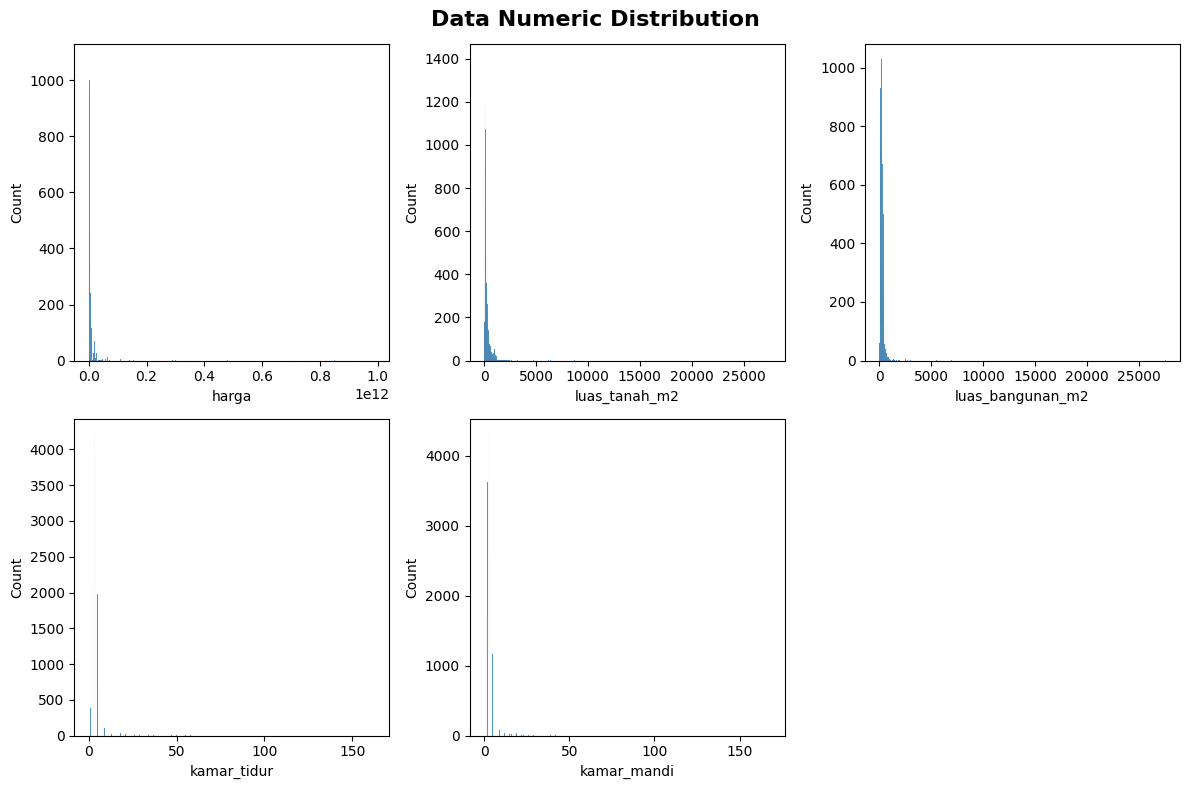

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

fig.suptitle("Data Numeric Distribution", fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data = df_clean, x=col, kde = False, ax=axes[i])
    
for j in range(i+1, 6):
    axes[j].remove()
    
plt.tight_layout()
plt.show()

# Feature Engineering